# **1. Entendimiento del problema:**
El gobierno australiano quiere conocer cuánto puede ser el costo de el uso de corticoides y esteroides en el sistema de salud actual para preparar sus finazas a futuro.

# **2. Enfoque Analítico:**
Vamos a construir un modelo de regresión basado en series de tiempo que permita estimar el costo de corticoides y esteroides con el menor MAE posible.

# **3. Requerimiento de Datos:**
Se requieren los datos pasados del costo de los medicamentos

# **4. Recolección de Datos**

In [2]:
import matplotlib.pyplot as plt
from skforecast.datasets import fetch_dataset

In [3]:
data = fetch_dataset(name = 'h2o_exog')
data.index.name = 'datetime'

╭─────────────────────────────────── h2o_exog ────────────────────────────────────╮
│ Description:                                                                    │
│ Monthly expenditure ($AUD) on corticosteroid drugs that the Australian health   │
│ system had between 1991 and 2008. Two additional variables (exog_1, exog_2) are │
│ simulated.                                                                      │
│                                                                                 │
│ Source:                                                                         │
│ Hyndman R (2023). fpp3: Data for Forecasting: Principles and Practice (3rd      │
│ Edition). http://pkg.robjhyndman.com/fpp3package/,                              │
│ https://github.com/robjhyndman/fpp3package, http://OTexts.com/fpp3.             │
│                                                                                 │
│ URL:                                                                            │
│ https://raw.githubusercontent.com/skforecast/skforecast-                        │
│ datasets/main/data/h2o_exog.csv                                                 │
│                                                                                 │
│ Shape: 195 rows x 3 columns                                                     │
╰─────────────────────────────────────────────────────────────────────────────────╯

In [4]:
data

,y,exog_1,exog_2
datetime,,,
1992-04-01,0.379808,0.958792,1.166029
1992-05-01,0.361801,0.951993,1.117859
1992-06-01,0.410534,0.952955,1.067942
1992-07-01,0.483389,0.958078,1.097376
1992-08-01,0.475463,0.956370,1.122199
...,...,...,...
2008-02-01,0.761822,1.515840,1.786373
2008-03-01,0.649435,1.506258,1.694264
2008-04-01,0.827887,1.505253,1.627135


# **5. Exploración de Datos**

- Identificar los patrones estacionales de la serie
- Determinar la estacioneridad de la serie

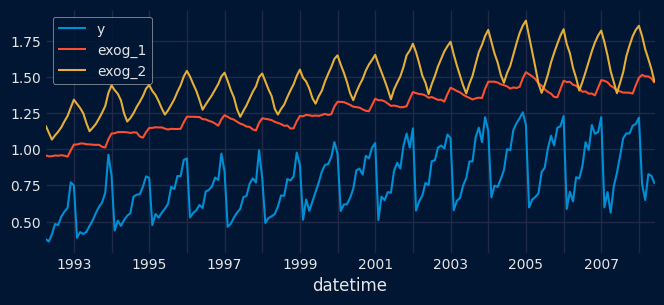

In [5]:
from skforecast.plot import set_dark_theme
set_dark_theme()
fig, ax = plt.subplots(figsize = (7, 3))
data.plot(ax = ax)
ax.legend()
plt.show()

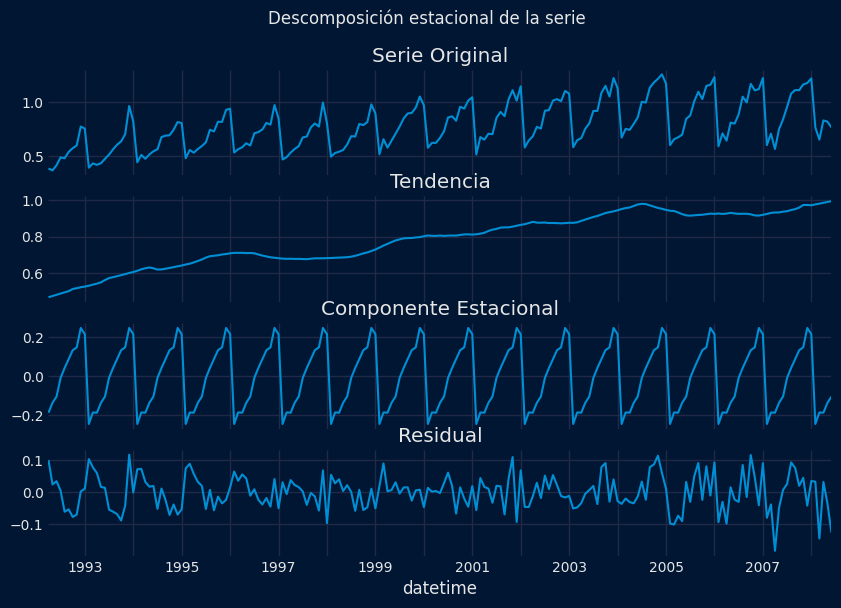

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose
res_decompose = seasonal_decompose(data['y'], model = 'additive', extrapolate_trend = 'freq')
fig, ax = plt.subplots(4, 1, figsize = (9, 6), sharex = True)
res_decompose.observed.plot(ax = ax[0])
ax[0].set_title('Serie Original')
res_decompose.trend.plot(ax = ax[1])
ax[1].set_title('Tendencia')
res_decompose.seasonal.plot(ax = ax[2])
ax[2].set_title('Componente Estacional')
res_decompose.resid.plot(ax = ax[3])
ax[3].set_title('Residual')
fig.suptitle('Descomposición estacional de la serie')
plt.show()

In [7]:
from statsmodels.tsa.stattools import adfuller
print('Test de Estacionariedad')
adfuller_result = adfuller(data['y'])
print(f'ADF Estadístico: {adfuller_result[0]}, p-value: {adfuller_result[1]}')

Test de Estacionariedad
ADF Estadístico: -1.5180458060933468, p-value: 0.5245662008648657


# **6. Preparación de los Datos**

- Diferenciar la serie
- Identificar su comportamiento estacional

Test de Estacionariedad
ADF Estadístico: -3.272501193023123, p-value: 0.016153320135666022


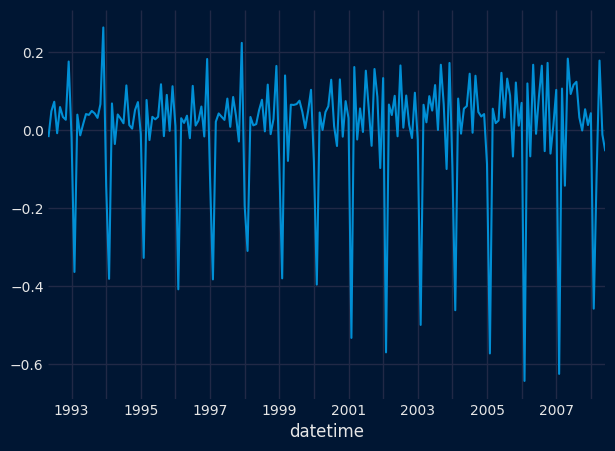

In [8]:
data_diff = data['y'].diff().dropna()
print('Test de Estacionariedad')
adfuller_result = adfuller(data_diff)
print(f'ADF Estadístico: {adfuller_result[0]}, p-value: {adfuller_result[1]}')
data_diff.plot()
plt.show()

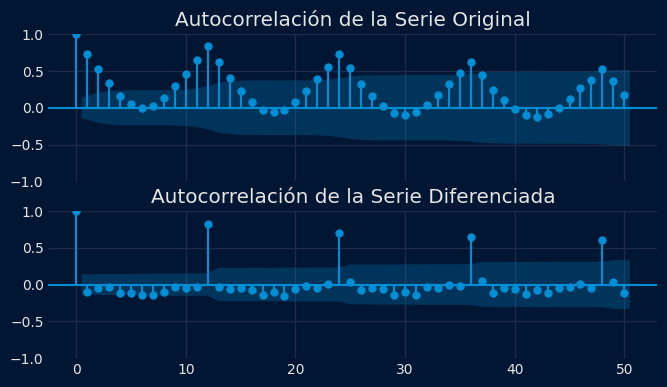

In [9]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
#Gráfico de Autocorrelación
fig, ax = plt.subplots(2, 1, figsize = (7, 4), sharex = True)
plot_acf(data['y'], ax = ax[0], lags = 50, alpha = 0.05)
ax[0].set_title('Autocorrelación de la Serie Original')
plot_acf(data_diff, ax = ax[1], lags = 50, alpha = 0.05)
ax[1].set_title('Autocorrelación de la Serie Diferenciada')
plt.show()

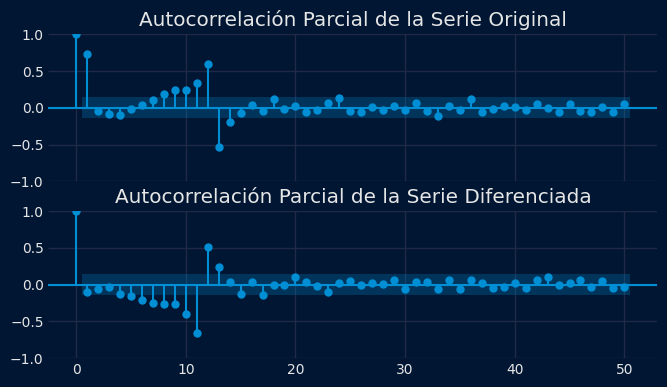

In [10]:
#Gráfico de Autocorrelación Parcial
fig, ax = plt.subplots(2, 1, figsize = (7, 4), sharex = True)
plot_pacf(data['y'], ax = ax[0], lags = 50, alpha = 0.05)
ax[0].set_title('Autocorrelación Parcial de la Serie Original')
plot_pacf(data_diff, ax = ax[1], lags = 50, alpha = 0.05)
ax[1].set_title('Autocorrelación Parcial de la Serie Diferenciada')
plt.show()

In [11]:
#diferenciación de la serie estacionaria
data_diff_12 = data['y'].diff().diff(12).dropna()

adfuller_result = adfuller(data_diff_12)
print(f'ADF Estadístico: {adfuller_result[0]}, p-value: {adfuller_result[1]}')

ADF Estadístico: -5.177607779376001, p-value: 9.766313840442693e-06


<Figure size 700x300 with 0 Axes>

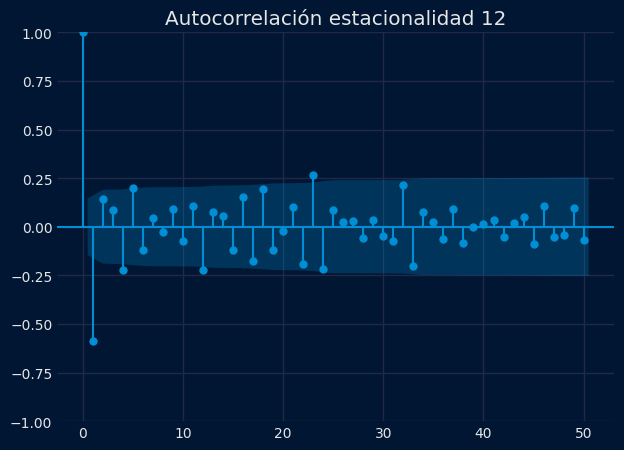

In [12]:
#Gráfico de autocorrelación de la serie estacionaria estacional
plt.figure(figsize = (7, 3))
plot_acf(data_diff_12, lags = 50, alpha = 0.05)
plt.title('Autocorrelación estacionalidad 12')
plt.show()

<Figure size 700x300 with 0 Axes>

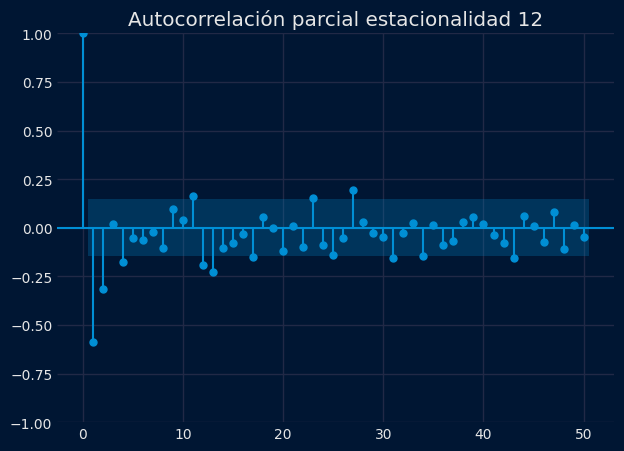

In [13]:
#Gráfico de autocorrelación parcial de la serie estacionaria estacional
plt.figure(figsize = (7, 3))
plot_pacf(data_diff_12, lags = 50, alpha = 0.05)
plt.title('Autocorrelación parcial estacionalidad 12')
plt.show()

In [14]:
#imputacion de nulos en series de tiempo (aparte)
import statsmodels.api as sm
import pandas as pd
df_serie = sm.datasets.get_rdataset("airquality").data
df_serie['year']=1973
df_serie['date'] = pd.to_datetime(df_serie[['year','Month','Day']])


df_serie.index = df_serie['date']
df_serie.drop(columns=['year','Month','Day','date'], inplace=True)

df_serie

,Ozone,Solar.R,Wind,Temp
date,,,,
1973-05-01,41.0,190.0,7.4,67
1973-05-02,36.0,118.0,8.0,72
1973-05-03,12.0,149.0,12.6,74
1973-05-04,18.0,313.0,11.5,62
1973-05-05,NaN,NaN,14.3,56
...,...,...,...,...
1973-09-26,30.0,193.0,6.9,70
1973-09-27,NaN,145.0,13.2,77
1973-09-28,14.0,191.0,14.3,75


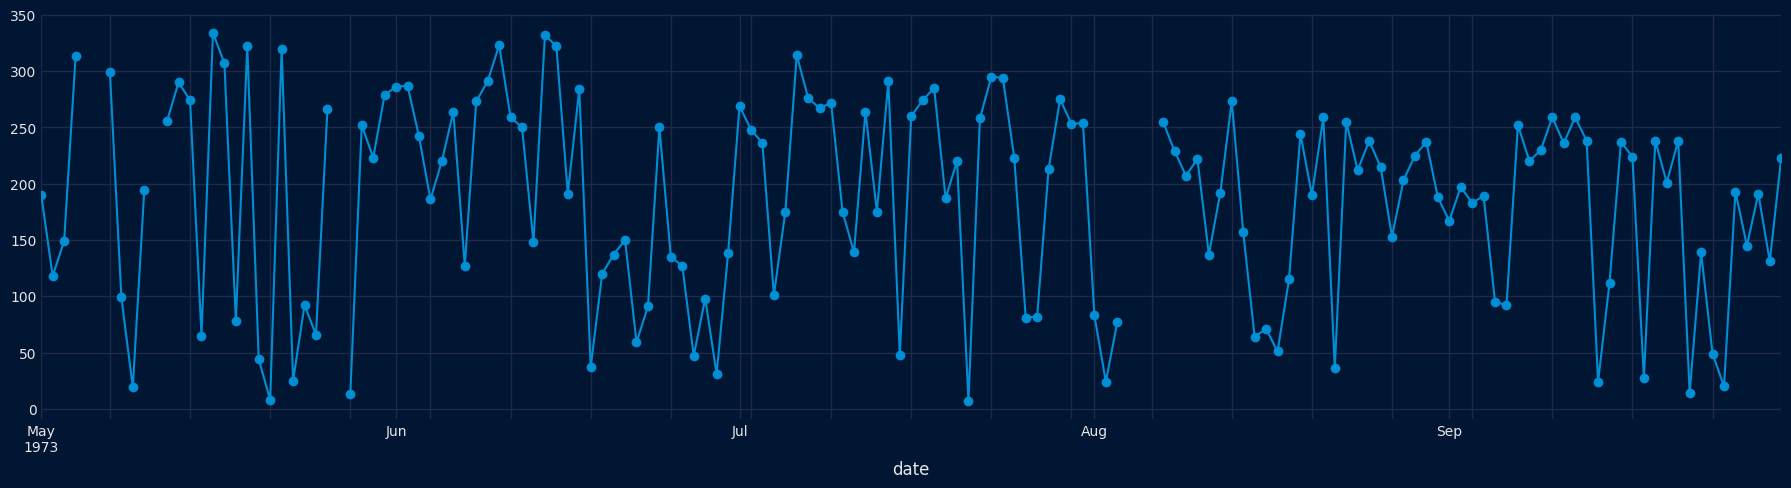

In [15]:
plt.figure(figsize=(20,5))
df_serie['Solar.R'].plot(marker='o')
plt.show()

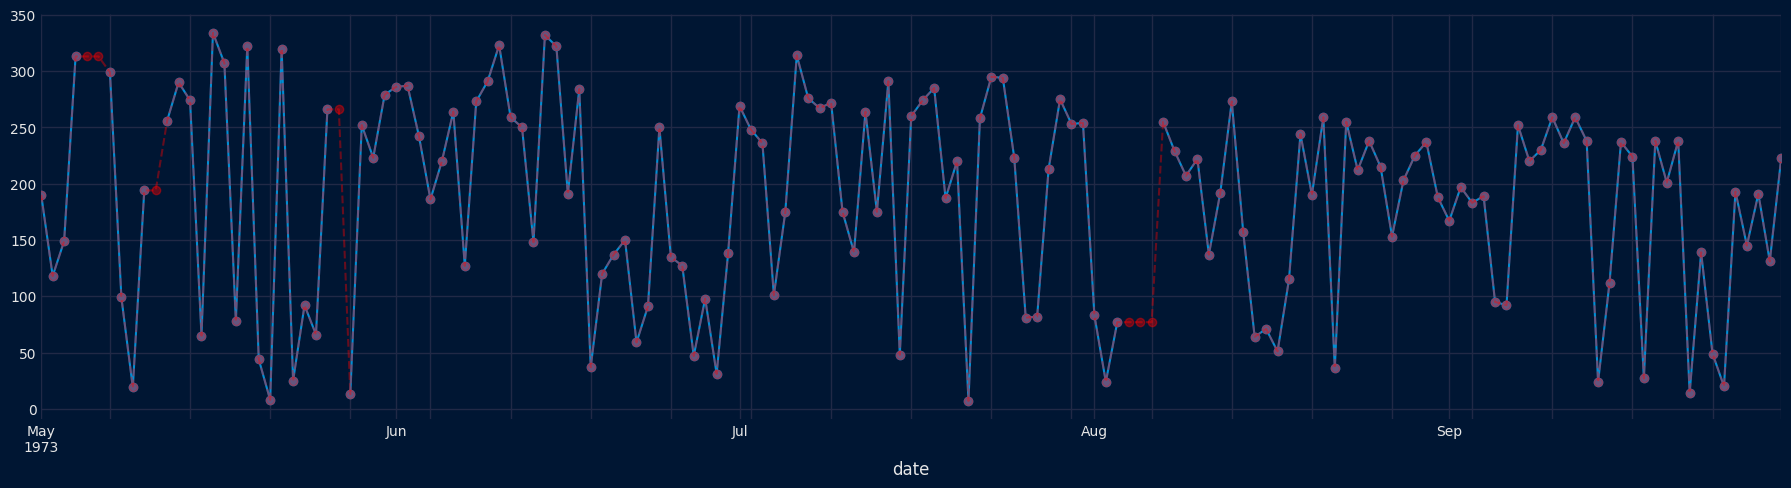

In [16]:
#imputacion por llenado hacia adelante
plt.figure(figsize=(20,5))
df_serie['Solar.R'].plot(marker='o')
df_serie['Solar.R'].ffill().plot(color='red',alpha=0.4,ls='dashed',marker='o')
plt.show()

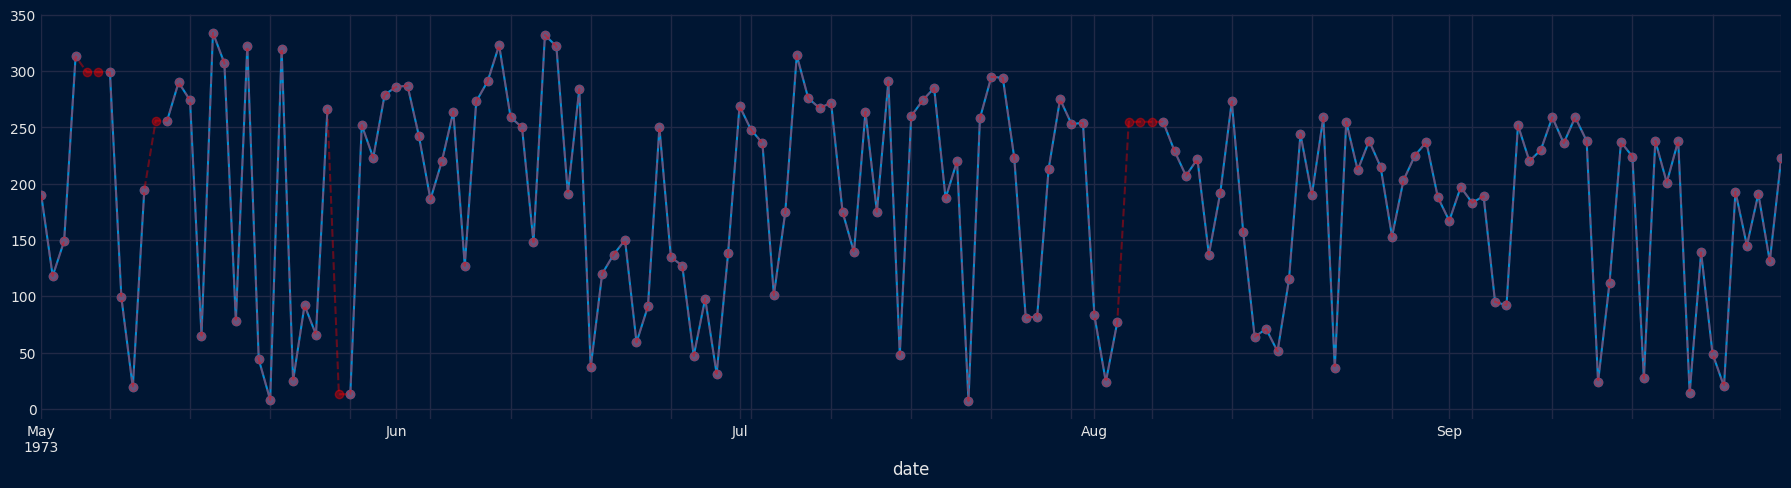

In [17]:
#imputacion por llenado hacia atras
plt.figure(figsize=(20,5))
df_serie['Solar.R'].plot(marker='o')
df_serie['Solar.R'].bfill().plot(color='red',alpha=0.4,ls='dashed',marker='o')
plt.show()

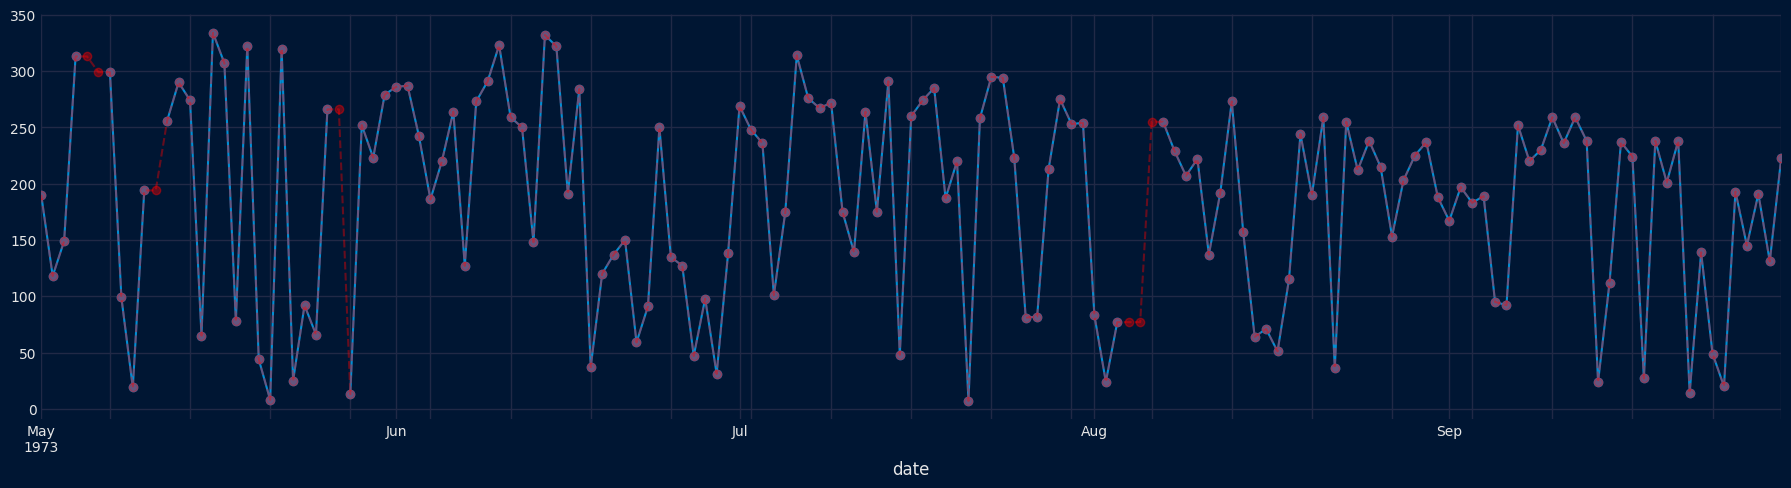

In [18]:
#imputacion por interpolacion por cercanía
plt.figure(figsize=(20,5))
df_serie['Solar.R'].plot(marker='o')
df_serie['Solar.R'].interpolate(method = 'nearest').plot(color='red',alpha=0.4,ls='dashed',marker='o')
plt.show()

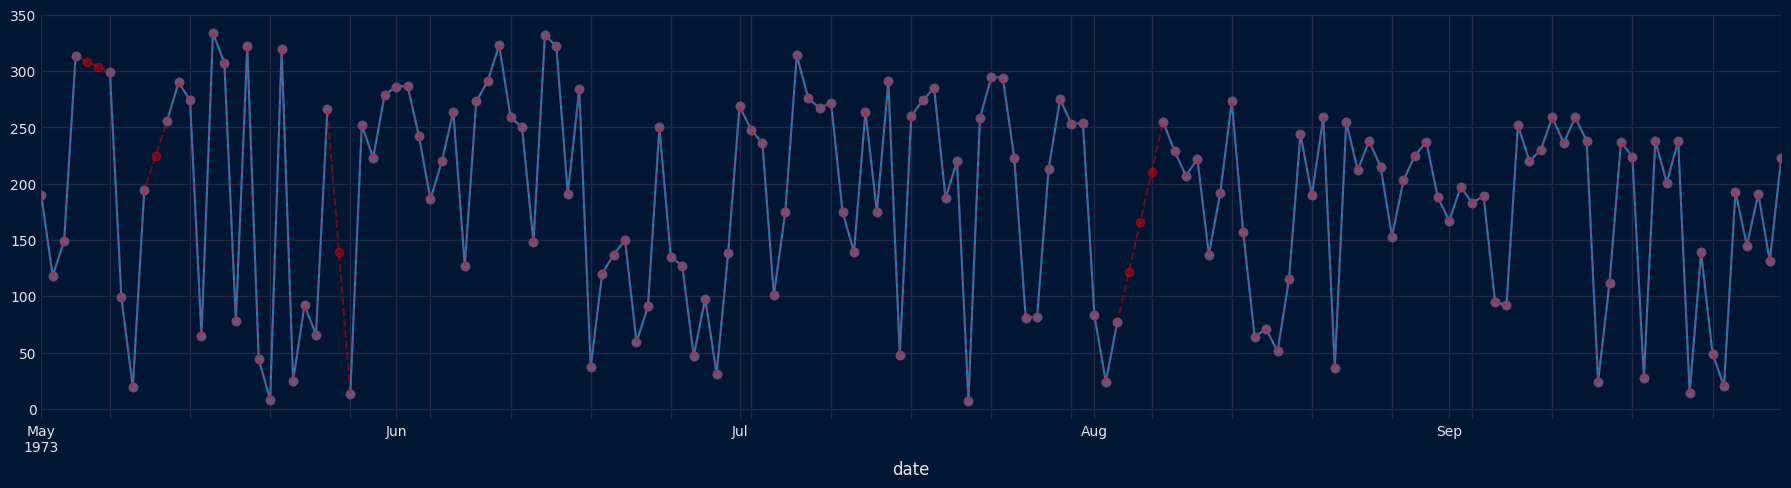

In [19]:
#imputacion por interpolacion lineal
plt.figure(figsize=(20,5))
df_serie['Solar.R'].plot(marker='o')
df_serie['Solar.R'].interpolate(method = 'linear').plot(color='red',alpha=0.4,ls='dashed',marker='o')
plt.show()

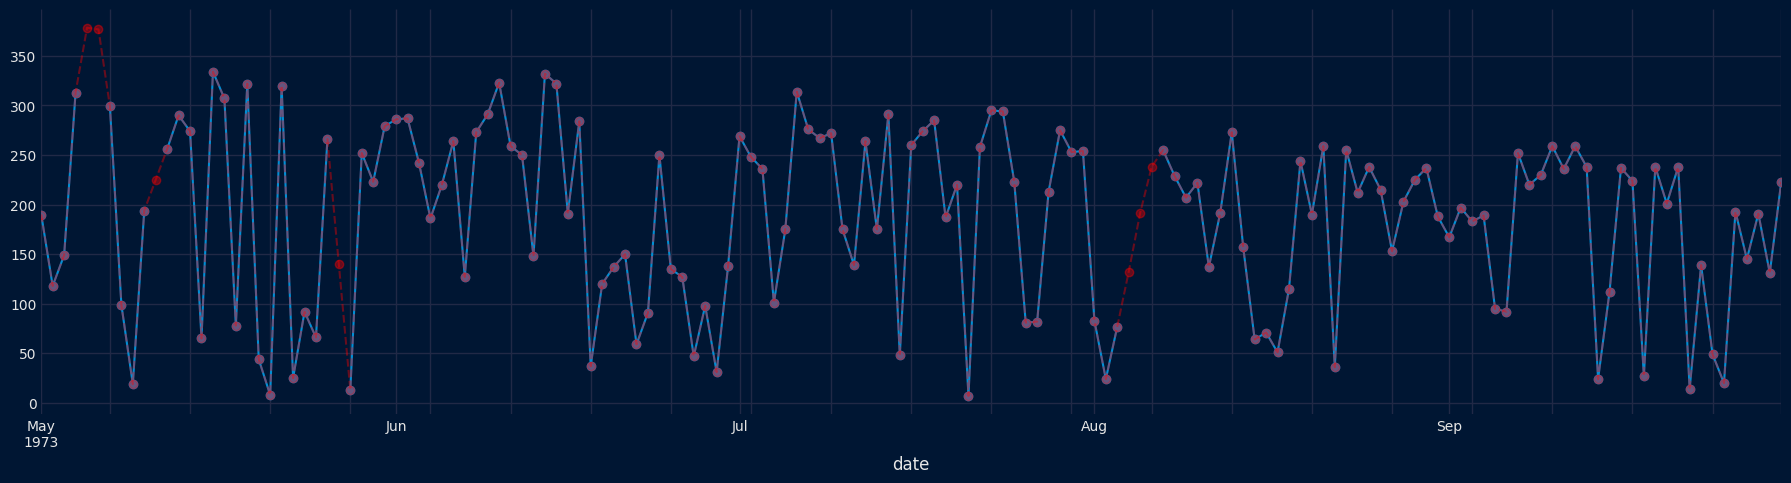

In [20]:
#imputacion por interpolacion por orden superior suavizadas
plt.figure(figsize=(20,5))
df_serie['Solar.R'].plot(marker='o')
df_serie['Solar.R'].interpolate(method = 'akima').plot(color='red',alpha=0.4,ls='dashed',marker='o')
plt.show()

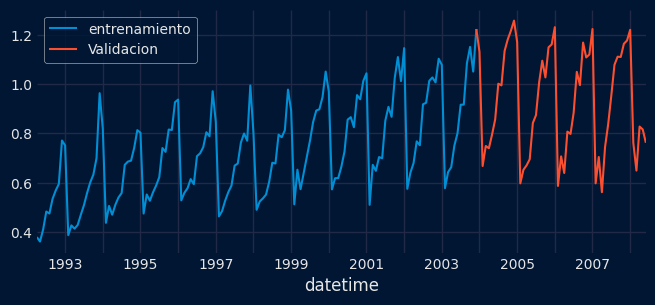

In [ ]:
#Separar entrenamiento y prueba
end_train = '2003-12-01'
data_train = data['y'].loc[:end_train]
data_test = data['y'].loc[end_train:]
plt.figure(figsize=(7,3))
data_train.plot(label='entrenamiento')



.plot(label='Validacion')
plt.legend()
plt.show()

 # Modelado

 sarimax
 forecast
 RNA Secuencial

In [22]:
#sarimax
from statsmodels.tsa.statespace.sarimax import SARIMAX
modelo_sarimax = SARIMAX(endog=data_train, order = (0, 1, 0), seasonal_order = (2, 1, 1, 12))
modelo_sarimax = modelo_sarimax.fit(disp = 0)
modelo_sarimax.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                  141
Model:             SARIMAX(0, 1, 0)x(2, 1, [1], 12)   Log Likelihood                 178.682
Date:                              Sat, 25 Oct 2025   AIC                           -349.363
Time:                                      00:33:20   BIC                           -337.955
Sample:                                  04-01-1992   HQIC                          -344.728
                                       - 12-01-2003                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L12       0.4029      0.204      1.971      0.049       0.002       0.803
ar.S.L24      -0.2289      0.132     -1.730      0.084      -0.488       0.030
ma.S.L12      -0.8184      0.262     -3.126      0.002      -1.332      -0.305
sigma2         0.0033      0.000      7.671      0.000       0.002       0.004
===================================================================================
Ljung-Box (L1) (Q):                  35.76   Jarque-Bera (JB):                13.03
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               2.58   Skew:                            -0.46
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.26
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [23]:
pred_sarimax = modelo_sarimax.get_forecast(steps = len(data_test)).predicted_mean
pred_sarimax.name = 'predicciones_sarimax'
display(pred_sarimax.head(4))

2004-01-01    1.153979
2004-02-01    0.719676
2004-03-01    0.792422
2004-04-01    0.791142
Freq: MS, Name: predicciones_sarimax, dtype: float64

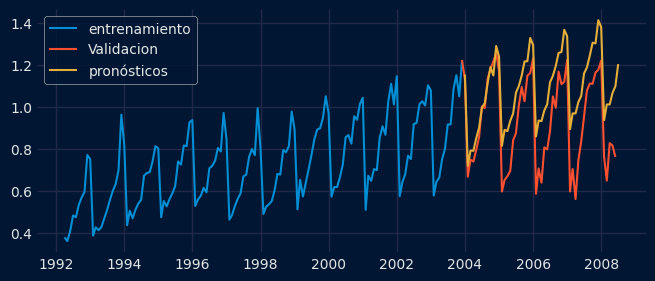

In [24]:
plt.figure(figsize=(7,3))
plt.plot(data_train,label='entrenamiento')
plt.plot(data_test,label='Validacion')
plt.plot(pred_sarimax,label='pronósticos')
plt.legend()
plt.show()

In [25]:
from sklearn.metrics import mean_absolute_percentage_error
mape_sarimax = mean_absolute_percentage_error(data_test, pred_sarimax)

mape_sarimax

0.2639618960663405

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from skforecast.recursive import ForecasterRecursive
from skforecast.preprocessing import RollingFeatures
from skforecast.plot import plot_prediction_intervals


C:\Users\Sebastian\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


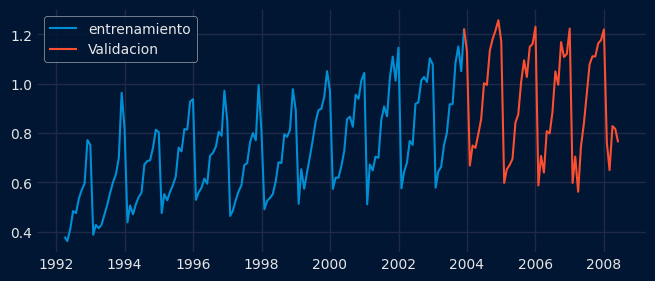

In [27]:
plt.figure(figsize=(7,3))
plt.plot(data_train,label='entrenamiento')
plt.plot(data_test,label='Validacion')
plt.legend()
plt.show()

In [28]:
forecaster_1 = ForecasterRecursive(regressor = LinearRegression(),lags = 15, window_features = RollingFeatures(stats=['mean'],window_sizes=10))
forecaster_1.fit(y = data_train,store_in_sample_residuals=True)
forecaster_1


=================== 
ForecasterRecursive 
=================== 
Regressor: LinearRegression 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15] 
Window features: ['roll_mean_10'] 
Window size: 15 
Series name: y 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('1992-04-01 00:00:00'), Timestamp('2003-12-01 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: MS 
Regressor parameters: 
    {'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False,
    'tol': 1e-06} 
fit_kwargs: {} 
Creation date: 2025-10-25 00:33:22 
Last fit date: 2025-10-25 00:33:22 
Skforecast version: 0.18.0 
Python version: 3.12.9 
Forecaster id: None

In [29]:
predictions_1 = forecaster_1.predict(steps = len(data_test))

predictions_1

2004-01-01    1.111554
2004-02-01    0.639690
2004-03-01    0.689112
2004-04-01    0.698062
2004-05-01    0.786592
2004-06-01    0.852667
2004-07-01    0.944152
2004-08-01    0.962054
2004-09-01    1.135455
2004-10-01    1.180984
2004-11-01    1.093922
2004-12-01    1.240321
2005-01-01    1.106812
2005-02-01    0.665317
2005-03-01    0.690337
2005-04-01    0.705423
2005-05-01    0.798573
2005-06-01    0.878663
2005-07-01    0.956437
2005-08-01    0.991798
2005-09-01    1.170185
2005-10-01    1.201430
2005-11-01    1.124880
2005-12-01    1.246809
2006-01-01    1.095354
2006-02-01    0.681203
2006-03-01    0.686018
2006-04-01    0.706667
2006-05-01    0.806932
2006-06-01    0.898985
2006-07-01    0.967262
2006-08-01    1.019203
2006-09-01    1.200567
2006-10-01    1.220776
2006-11-01    1.151890
2006-12-01    1.249643
2007-01-01    1.082657
2007-02-01    0.692560
2007-03-01    0.680140
2007-04-01    0.705687
2007-05-01    0.814464
2007-06-01    0.916657
2007-07-01    0.978775
2007-08-01 

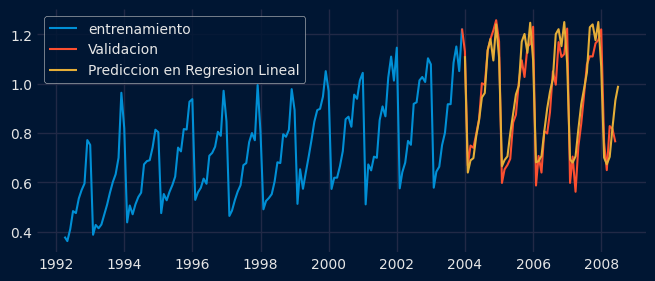

In [30]:
plt.figure(figsize=(7,3))
plt.plot(data_train,label='entrenamiento')
plt.plot(data_test,label='Validacion')
plt.plot(predictions_1,label='Prediccion en Regresion Lineal')
plt.legend()
plt.show()

In [31]:
mean_absolute_percentage_error(data_test, predictions_1)

0.14838096190284897

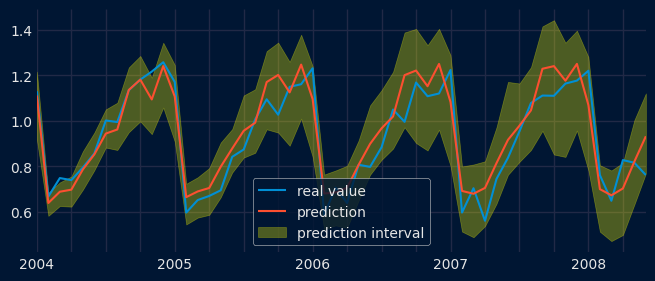

In [32]:
#graficar intervalor de predicción

predictions_1_intervals=forecaster_1.predict_interval(steps=len(data_test)-1,interval=[5,95],method='bootstrapping',n_boot=100)

plot_prediction_intervals(predictions=predictions_1_intervals,y_true=data_test,target_variable='y',kwargs_fill_between={'color':'yellow','alpha':0.3})
plt.show()

In [33]:
forecaster_2 = ForecasterRecursive(regressor = DecisionTreeRegressor(random_state=42),lags = 15, window_features = RollingFeatures(stats=['mean'],window_sizes=10))
forecaster_2.fit(y = data_train,store_in_sample_residuals=True)
forecaster_2


=================== 
ForecasterRecursive 
=================== 
Regressor: DecisionTreeRegressor 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15] 
Window features: ['roll_mean_10'] 
Window size: 15 
Series name: y 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('1992-04-01 00:00:00'), Timestamp('2003-12-01 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: MS 
Regressor parameters: 
    {'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None,
    'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0,
    'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf':
    0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'} 
fit_kwargs: {} 
Creation date: 2025-10-25 00:33:23 
Last fit date: 2025-10-25 00:33:23 
Skforecast version: 0.18.0 
Python version: 3.12.9 
Forecaster id: None

In [34]:
predictions_2 = forecaster_2.predict(steps = len(data_test))

predictions_2.head(3)

2004-01-01    1.078145
2004-02-01    0.618996
2004-03-01    0.726520
Freq: MS, Name: pred, dtype: float64

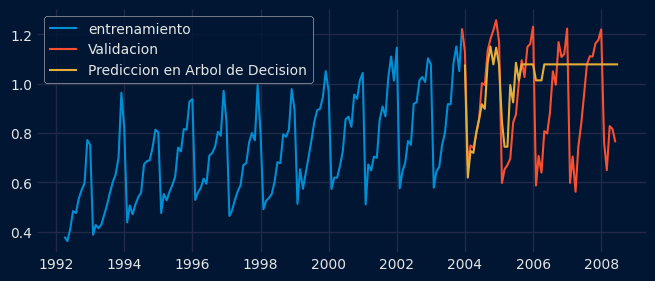

In [35]:
plt.figure(figsize=(7,3))
plt.plot(data_train,label='entrenamiento')
plt.plot(data_test,label='Validacion')
plt.plot(predictions_2,label='Prediccion en Arbol de Decision')
plt.legend()
plt.show()

In [36]:
from skforecast.model_selection import grid_search_forecaster,random_search_forecaster,TimeSeriesFold
forecaster_2= ForecasterRecursive(regressor=DecisionTreeRegressor(random_state=42),lags=10)

#Búsqueda de la ventana

lags_grid = {'lags_1':3,'lags_2':10,'lags_3':[1,2,3,12]}

#Búsqueda de hiperparámetros del regresor

param_grid = {
    'max_depth': [5,10,20],'criterion': ['squared_error','poisson','friedman_mse','absolute_error']}

#Folds

cv = TimeSeriesFold(steps=12,initial_train_size=len(data_test),refit=False)

#Implementacion de la busqueda

results = grid_search_forecaster(
    forecaster = forecaster_2,
    y = data_train,
    param_grid = param_grid,
    lags_grid = lags_grid,
    cv = cv,
    metric = 'mean_squared_error',
    return_best = True,
    n_jobs = -1,
    verbose = False,
    show_progress=True
)

results

lags grid: 100%|██████████| 3/3 [00:08<00:00,  2.95s/it]

`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2  3 12] 
  Parameters: {'criterion': 'absolute_error', 'max_depth': 5}
  Backtesting metric: 0.008137813902720652


,lags,lags_label,params,mean_squared_error,criterion,max_depth
0,"[1, 2, 3, 12]",lags_3,"{'criterion': 'absolute_error', 'max_depth': 5}",0.008138,absolute_error,5
1,"[1, 2, 3, 12]",lags_3,"{'criterion': 'absolute_error', 'max_depth': 20}",0.008439,absolute_error,20
2,"[1, 2, 3, 12]",lags_3,"{'criterion': 'absolute_error', 'max_depth': 10}",0.008439,absolute_error,10
3,"[1, 2, 3, 12]",lags_3,"{'criterion': 'friedman_mse', 'max_depth': 20}",0.009701,friedman_mse,20
4,"[1, 2, 3, 12]",lags_3,"{'criterion': 'friedman_mse', 'max_depth': 10}",0.009701,friedman_mse,10
5,"[1, 2, 3, 12]",lags_3,"{'criterion': 'squared_error', 'max_depth': 20}",0.009774,squared_error,20
6,"[1, 2, 3, 12]",lags_3,"{'criterion': 'squared_error', 'max_depth': 10}",0.009774,squared_error,10
7,"[1, 2, 3, 12]",lags_3,"{'criterion': 'friedman_mse', 'max_depth': 5}",0.009899,friedman_mse,5
8,"[1, 2, 3, 12]",lags_3,"{'criterion': 'squared_error', 'max_depth': 5}",0.009899,squared_error,5
9,"[1, 2, 3, 12]",lags_3,"{'criterion': 'poisson', 'max_depth': 5}",0.021059,poisson,5


In [37]:
forecaster_2

=================== 
ForecasterRecursive 
=================== 
Regressor: DecisionTreeRegressor 
Lags: [ 1  2  3 12] 
Window features: None 
Window size: 12 
Series name: y 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('1992-04-01 00:00:00'), Timestamp('2003-12-01 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: MS 
Regressor parameters: 
    {'ccp_alpha': 0.0, 'criterion': 'absolute_error', 'max_depth': 5,
    'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0,
    'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf':
    0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'} 
fit_kwargs: {} 
Creation date: 2025-10-25 00:33:23 
Last fit date: 2025-10-25 00:33:32 
Skforecast version: 0.18.0 
Python version: 3.12.9 
Forecaster id: None

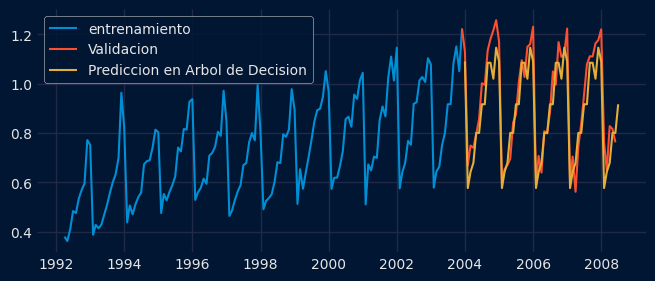

In [38]:
predictions_2 = forecaster_2.predict(steps = len(data_test))
plt.figure(figsize=(7,3))
plt.plot(data_train,label='entrenamiento')
plt.plot(data_test,label='Validacion')
plt.plot(predictions_2,label='Prediccion en Arbol de Decision')
plt.legend()
plt.show()

In [39]:
mean_absolute_percentage_error(data_test, predictions_2)

0.11941843098736717

In [40]:
forecaster_3= ForecasterRecursive(regressor=RandomForestRegressor(random_state=42),lags=10)

#Búsqueda de la ventana

lags_grid = {'lags_1':3,'lags_2':10,'lags_3':[1,2,3,12]}

#Búsqueda de hiperparámetros del regresor

param_grid = {
    'max_depth': [5,10,20],'criterion': ['squared_error','poisson','friedman_mse','absolute_error'],'n_estimators':[100,200,300]}

#Folds

cv = TimeSeriesFold(steps=12,initial_train_size=len(data_test),refit=False)

#Implementacion de la busqueda

results = grid_search_forecaster(
    forecaster = forecaster_3,
    y = data_train,
    param_grid = param_grid,
    lags_grid = lags_grid,
    cv = cv,
    metric = 'mean_squared_error',
    return_best = True,
    n_jobs = -1,
    verbose = False,
    show_progress=True
)

results

lags grid: 100%|██████████| 3/3 [00:34<00:00, 11.45s/it]

`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [ 1  2  3 12] 
  Parameters: {'criterion': 'squared_error', 'max_depth': 5, 'n_estimators': 100}
  Backtesting metric: 0.011898283156282243


,lags,lags_label,params,mean_squared_error,criterion,max_depth,n_estimators
0,"[1, 2, 3, 12]",lags_3,"{'criterion': 'squared_error', 'max_depth': 5,...",0.011898,squared_error,5,100
1,"[1, 2, 3, 12]",lags_3,"{'criterion': 'poisson', 'max_depth': 5, 'n_es...",0.012169,poisson,5,100
2,"[1, 2, 3, 12]",lags_3,"{'criterion': 'friedman_mse', 'max_depth': 5, ...",0.012217,friedman_mse,5,100
3,"[1, 2, 3, 12]",lags_3,"{'criterion': 'squared_error', 'max_depth': 20...",0.012255,squared_error,20,300
4,"[1, 2, 3, 12]",lags_3,"{'criterion': 'squared_error', 'max_depth': 10...",0.012255,squared_error,10,300
...,...,...,...,...,...,...,...
103,"[1, 2, 3]",lags_1,"{'criterion': 'friedman_mse', 'max_depth': 10,...",0.058632,friedman_mse,10,300
104,"[1, 2, 3]",lags_1,"{'criterion': 'poisson', 'max_depth': 5, 'n_es...",0.058792,poisson,5,300
105,"[1, 2, 3]",lags_1,"{'criterion': 'friedman_mse', 'max_depth': 5, ...",0.058869,friedman_mse,5,300
106,"[1, 2, 3]",lags_1,"{'criterion': 'poisson', 'max_depth': 10, 'n_e...",0.058931,poisson,10,300


In [41]:
forecaster_3

=================== 
ForecasterRecursive 
=================== 
Regressor: RandomForestRegressor 
Lags: [ 1  2  3 12] 
Window features: None 
Window size: 12 
Series name: y 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('1992-04-01 00:00:00'), Timestamp('2003-12-01 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: MS 
Regressor parameters: 
    {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth':
    5, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None,
    'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2,
    'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100,
    'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0,
    'warm_start': False} 
fit_kwargs: {} 
Creation date: 2025-10-25 00:33:32 
Last fit date: 2025-10-25 00:34:06 
Skforecast version: 0.18.0 
Python version: 3.12.9 
Forecaster id: None

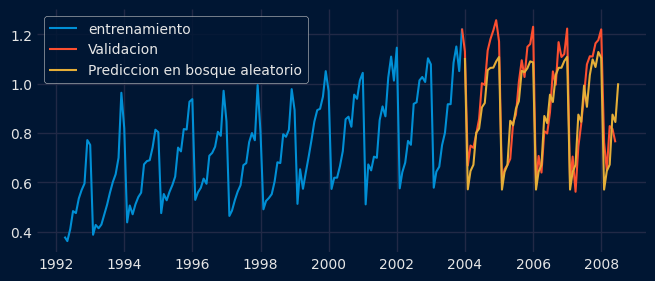

In [42]:
predictions_3 = forecaster_3.predict(len(data_test))

plt.figure(figsize=(7,3))
plt.plot(data_train,label='entrenamiento')
plt.plot(data_test,label='Validacion')
plt.plot(predictions_3,label='Prediccion en bosque aleatorio')
plt.legend()
plt.show()

In [43]:
mean_absolute_percentage_error(data_test,predictions_3)

0.13219829139884562

In [44]:
#Redes neuronales artificiales

from skforecast.deep_learning import ForecasterRnn, create_and_compile_model
from keras.optimizers import Adam
from keras.losses import MeanAbsoluteError
from keras.callbacks import EarlyStopping,reduceLROnPlateau

from sklearn.preprocessing import MinMaxScaler

ModuleNotFoundError: No module named '(C:\\Users\\Sebastian\\AppData\\Roaming\\Python\\Python312\\site-packages\\google\\protobuf\\__init__'

In [ ]:
model_rna = create_and_compile_model(series = pd.DataFrame(data_train),
                                     levels = ['y'],
                                     lags = 24,
                                     steps = 1,
                                     recurrent_layer = 'RNN',
                                     recurrent_units = 100,
                                     #recurrent
                                     dense_units = 64)


model_rna.summary()

NameError: name 'create_and_compile_model' is not defined

In [ ]:
forecaster_4 = ForecasterRnn(regressor=model_rna,
                             levels = ['y'],
                             lags=24,
                             transformer_series=MinMaxScaler(),
                             fit_kwargs={'epochs':25, 'batch_size':512,'callbacks':[EarlyStopping(monitor='val_loss',restore_best_weights=True)],
                                         'series_val':pd.DataFrame(data_test)})
                             

forecaster_4.fit()

NameError: name 'ForecasterRnn' is not defined

In [ ]:
forecaster_4


In [ ]:

grid,axis = plt.subplots(figsize=(8,3))
forecaster_4.plot_history(ax=axis)



In [ ]:
from skforecast.model_selection import backtesting_forecaster
cv= TimeSeriesFold(steps=forecaster_4.max_step,
                   initial_train_size=len(data_test),
                   refit=True)

metrics,predictions_4 = backtesting_forecaster(forecaster=forecaster_4,
                                               series=pd.DataFrame(data_train),
                                               cv=cv,
                                               levels=forecaster_4.levels,
                                               metric='mean_squared_error',
                                               verbose=False
                                               )

In [ ]:
metrics


In [1]:
plt.plot(predictions_4['pred'])

#arima , decidir modelo de mahcine learning, red recurrent y lstm

NameError: name 'plt' is not defined

In [ ]:
#arima, foirecaster de arbol de decision con busqueda hiper, red neuronal: la mejor capa recurenet con lstm